In [0]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES_V4= [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # consistency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES_V4].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V4)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
n = 4 # 3-4 clusters are consider for business personas

In [0]:
X4= base[CLUSTER_FEATURES_V4].copy()

scaler = PowerTransformer(
    method='yeo-johnson',
    standardize=True
)

X4_scaled = scaler.fit_transform(X4)
X4 = pd.DataFrame(
    X4_scaled,
    columns = CLUSTER_FEATURES_V4,
    index = base.index
)

gmm4 = GaussianMixture(
    n_components = n,
    covariance_type = 'spherical',
    n_init=20,
    max_iter=100,
    random_state = 42
)


In [0]:
labels4= gmm4.fit_predict(X4)
bic4 = gmm4.bic(X4)

sil_avg_4= silhouette_score(X4, labels4)
base_iter4 = base.copy()
base_iter4['cluster']= labels4
print(f'bic: {round(bic4 ,2)}')
print(f' Silhoutte: {round(sil_avg_4,2)}')
sizes4 = base_iter4['cluster'].value_counts().sort_index()
sizes4


bic: 2034361.24
 Silhoutte: 0.16


cluster
0    23062
1    46787
2    21104
3    17047
Name: count, dtype: int64

In [0]:
means4= (
    base_iter4.groupby('cluster')[CLUSTER_FEATURES_V4].mean().round(3))

In [0]:
profile4 = means4.copy()
profile4.insert(0, 'cluster_size', sizes4)
display(profile4)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
23062,48.61960193515174,1.0,24.90029753539479,48.61960193515174,0.275,0.39538609715794004,0.48399727955037797
46787,16.63084760069868,1.087,20.234005535930425,16.065712544905004,0.391,0.25419612566458794,0.4920044696205037
21104,52.51377360499676,1.0,18.448948079705627,52.51377360499676,0.268,0.21964502638191488,0.6920433114053263
17047,90.07638248137856,2.713,22.072070981457404,33.60129485338933,0.287,0.3086930296115729,0.5833712495536206


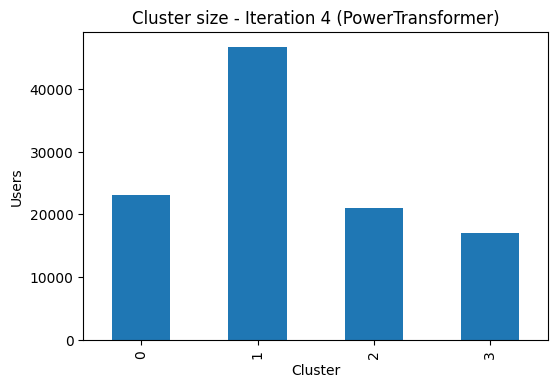

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4)) 

base_iter4['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 4 (PowerTransformer)')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

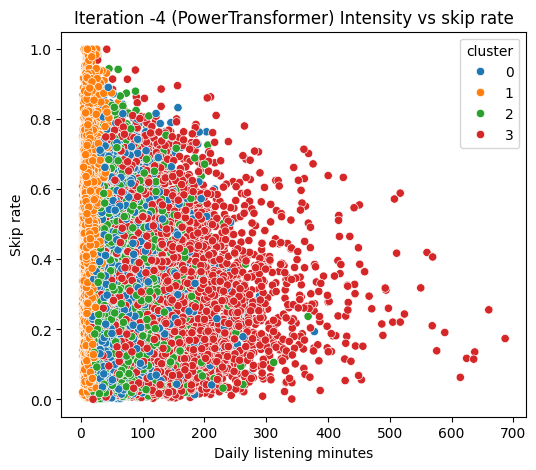

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter4,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration -4 (PowerTransformer) Intensity vs skip rate')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

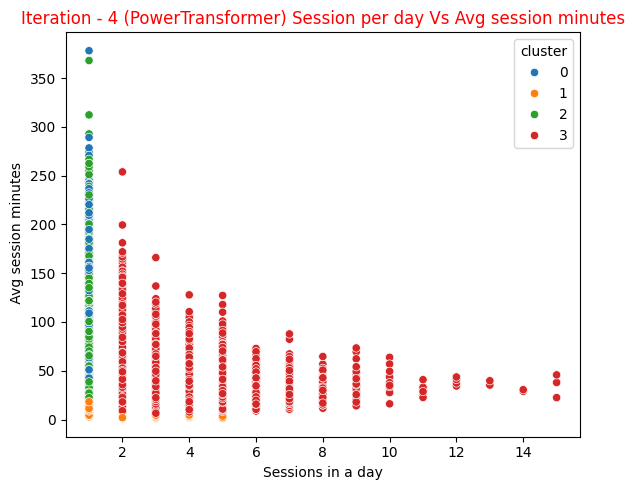

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter4,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 4 (PowerTransformer) Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

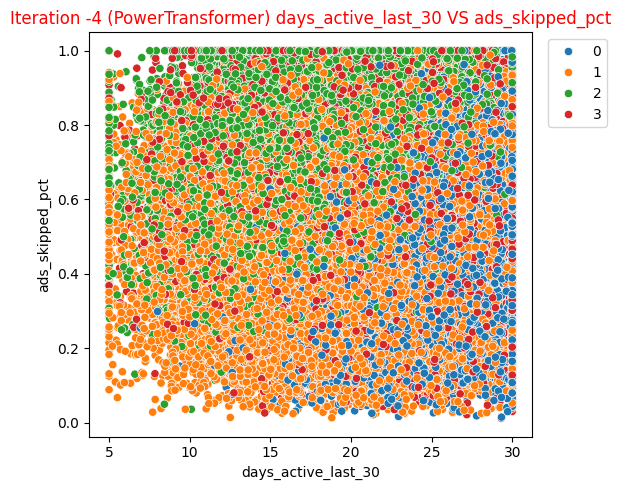

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter4,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration -4 (PowerTransformer) days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

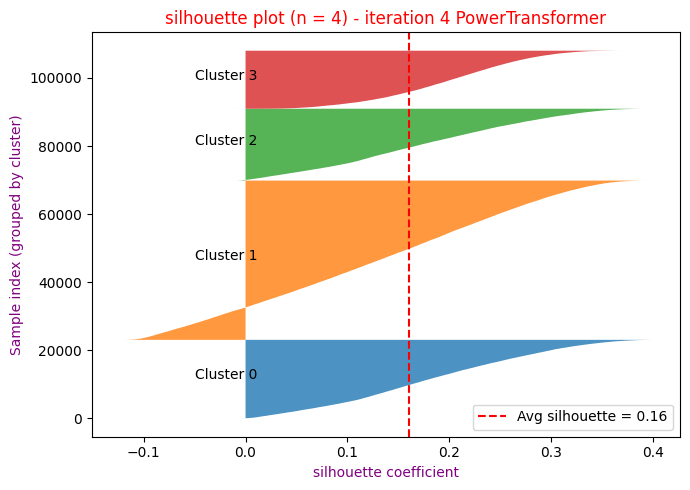

In [0]:
# silhouette Plot

sil_values_4 = silhouette_samples(X4, labels4)
sil_avg_4 = silhouette_score(X4, labels4)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_4[labels4 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_4[labels4==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_4[labels4 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_4[labels4 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_4,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_4:.2f}"
)

plt.title('silhouette plot (n = 4) - iteration 4 PowerTransformer', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show